# 1. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# 2. LOAD DATA

In [2]:
df = pd.read_csv("Mobile Price Classification.csv")
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [3]:
print("\nInfo:\n")
print(df.info())
print("\nShape:", df.shape)


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  

# 3. Exploratory Data Analysis (EDA)

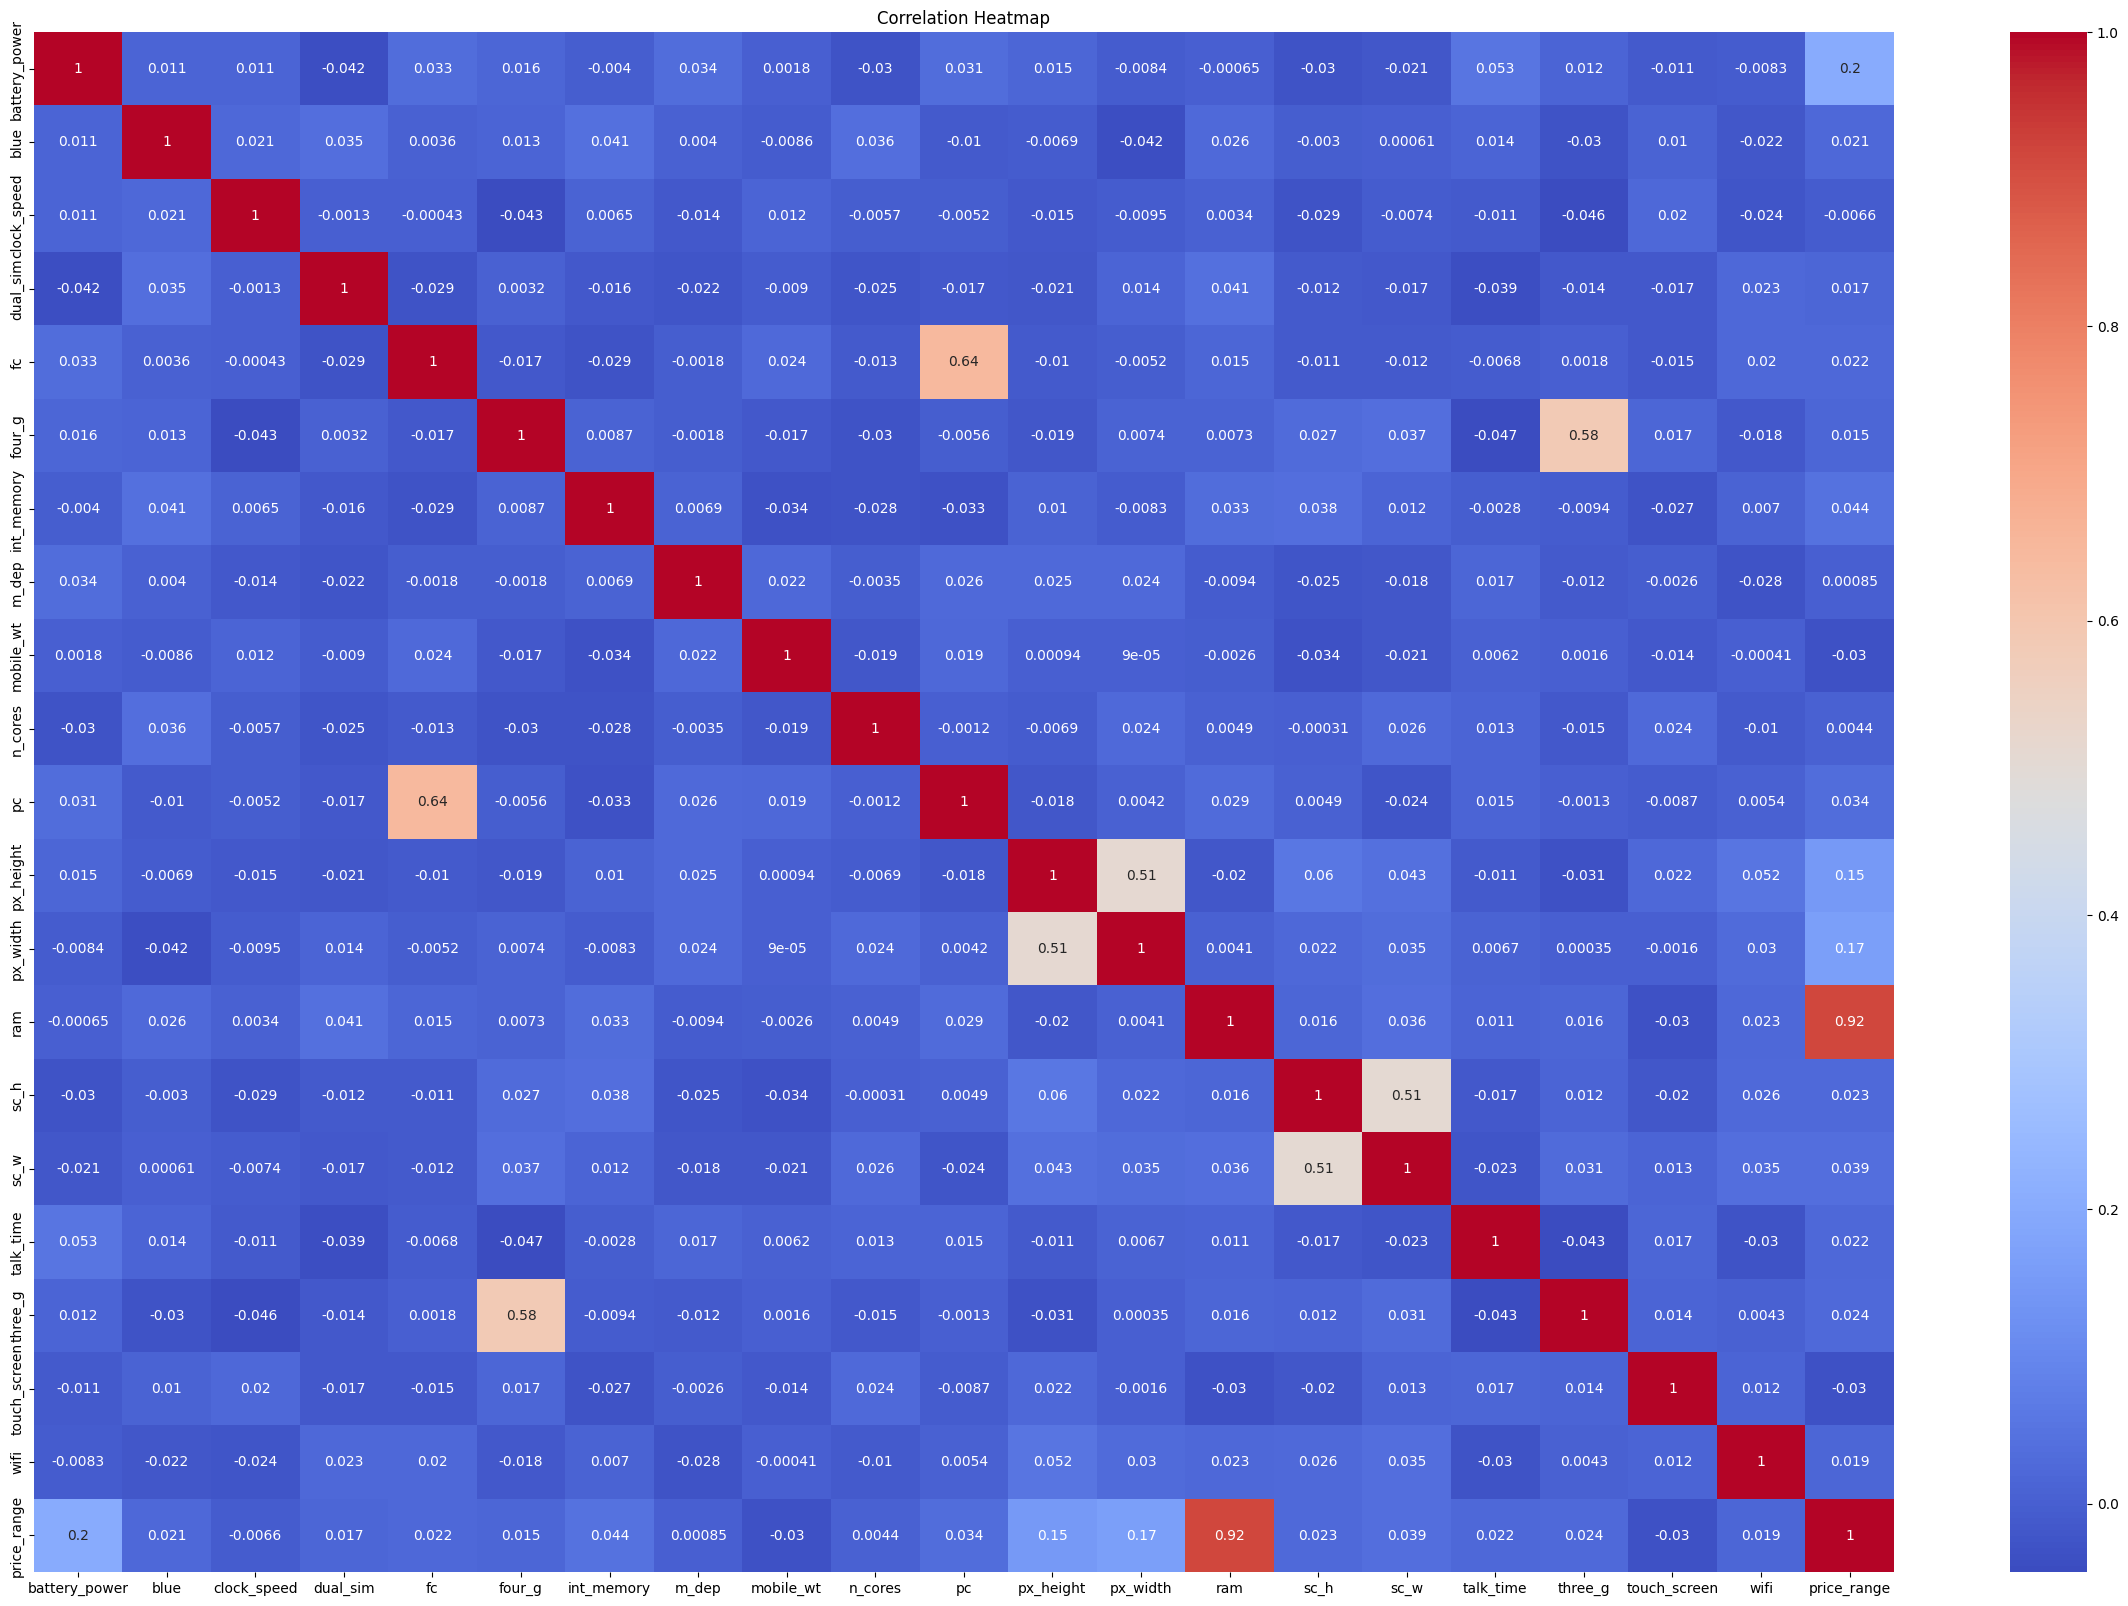

In [8]:
plt.figure(figsize = (30, 20))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 4. SPLIT DATA

In [10]:
X = df.drop("price_range", axis = 1)
y = df["price_range"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

# 5. DEFINE MODELS

In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter = 1000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ]),

    "Random Forest": RandomForestClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(eval_metric = 'mlogloss', use_label_encoder = False)
}

# 6. HYPERPARAMETER GRIDS

In [13]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ['scale', 0.01, 0.001]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1]
    },

    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 6, 10],
        "learning_rate": [0.01, 0.1]
    }
}

# 7. TRAINING + TUNING

In [14]:
results = {}
best_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    search = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=10,
        cv = 5,
        scoring = "accuracy",
        n_jobs = -1,
        random_state = 42
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print("Best Params:", search.best_params_)

    # Prediction
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc
    best_models[name] = best_model

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))




Training Logistic Regression...


c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__C': 10}
Logistic Regression Accuracy: 0.9750
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.98      0.96      0.97       100
           2       0.95      0.98      0.97       100
           3       0.98      0.98      0.98       100

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.98       400
weighted avg       0.98      0.97      0.98       400


Training SVM...


c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__gamma': 0.01, 'model__C': 10}
SVM Accuracy: 0.9400
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       100
           1       0.93      0.90      0.91       100
           2       0.93      0.93      0.93       100
           3       0.95      0.98      0.97       100

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400


Training Random Forest...


...

Best Params: {'n_estimators': 200, 'max_depth': 10}
Random Forest Accuracy: 0.8700
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       100
           1       0.79      0.81      0.80       100
           2       0.81      0.77      0.79       100
           3       0.94      0.94      0.94       100

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400


Training Gradient Boosting...


c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'n_estimators': 200, 'learning_rate': 0.1}
Gradient Boosting Accuracy: 0.9300
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.93      0.90      0.91       100
           2       0.87      0.90      0.89       100
           3       0.95      0.94      0.94       100

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400


Training XGBoost...


c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:22:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
XGBoost Accuracy: 0.9325
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       100
           1       0.92      0.93      0.93       100
           2       0.90      0.88      0.89       100
           3       0.95      0.93      0.94       100

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



# 8. MODEL COMPARISON PLOT

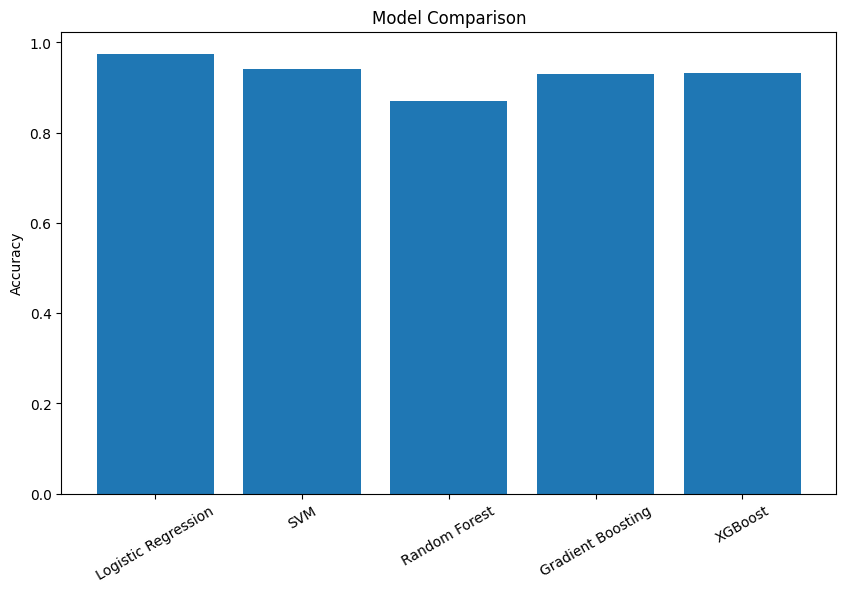

In [15]:
results_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])

plt.figure(figsize = (10,6))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation = 30)
plt.show()

# 9. CROSS VALIDATION

In [16]:
cv_scores = {}

for name, model in best_models.items():
    scores = cross_val_score(model, X, y, cv = 5)
    cv_scores[name] = scores

cv_df = pd.DataFrame(cv_scores)

print("\nCross Validation Scores:\n", cv_df)

c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:23:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:24:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Kalluru Prem\Desktop\Codes\myenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:24:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserW


Cross Validation Scores:
    Logistic Regression     SVM  Random Forest  Gradient Boosting  XGBoost
0               0.9700  0.9275         0.8675             0.9025   0.9100
1               0.9625  0.9075         0.8900             0.9150   0.9300
2               0.9800  0.9375         0.8900             0.9050   0.9200
3               0.9750  0.9200         0.8725             0.9125   0.9075
4               0.9775  0.9300         0.8625             0.8925   0.8975


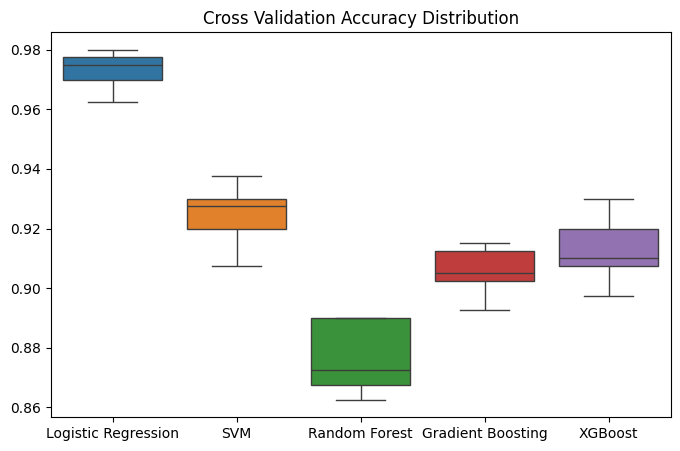

In [17]:
# Boxplot
plt.figure(figsize = (8,5))
sns.boxplot(data = cv_df)
plt.title("Cross Validation Accuracy Distribution")
plt.show()

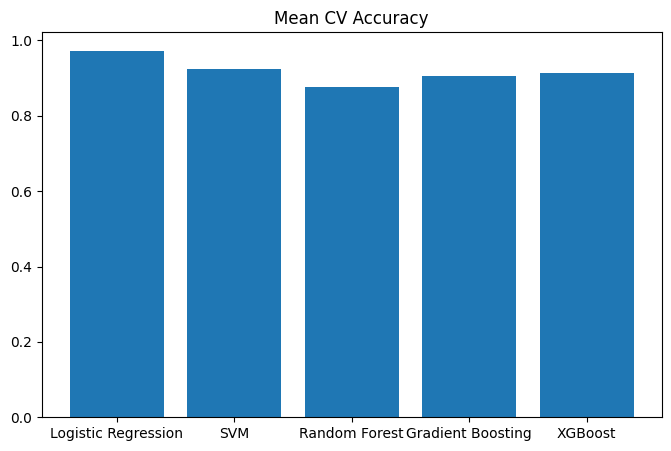

In [18]:
# Mean plot
plt.figure(figsize = (8,5))
plt.bar(cv_df.columns, cv_df.mean())
plt.title("Mean CV Accuracy")
plt.show()

# 10. BEST MODEL

In [19]:
best_model_name = max(results, key = results.get)
best_model = best_models[best_model_name]

print("\nBEST MODEL:", best_model_name)
print("Accuracy:", results[best_model_name])


BEST MODEL: Logistic Regression
Accuracy: 0.975


# 11. CONFUSION MATRIX

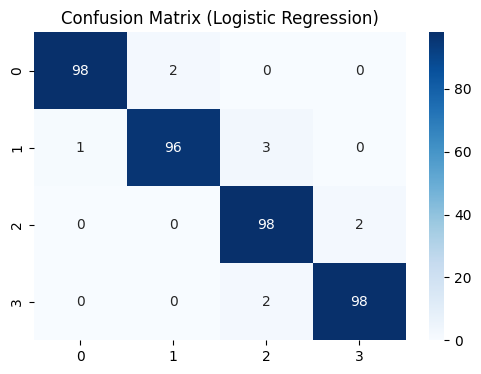

In [20]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize = (6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best),
            annot = True, fmt = 'd', cmap = 'Blues')
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

# 11. CONFUSION MATRIX

In [30]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    features = X.columns

    df_imp = pd.DataFrame({
        "Feature": features,
        "Importance": importances
    }).sort_values(by = "Importance", ascending = False)

    print("\nTop Features:\n", df_imp.head())

    plt.figure(figsize = (8,5))
    plt.barh(df_imp["Feature"], df_imp["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.show()